<a href="https://colab.research.google.com/github/kshitij-nandanwar/NNDL-Lab/blob/main/NNDL_Practical_8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ============================================================
# CELL 1: Install and import required libraries
# ============================================================

# We avoid using '-U' on numpy/pandas to prevent breaking binary compatibility with pre-installed SciPy in Colab
!pip -q install scikit-learn pandas numpy matplotlib seaborn

import os
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    mean_squared_error
)

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Environment ready.")

Environment ready.


In [2]:
# ============================================================
# CELL 2: Download MNIST automatically
# ============================================================

DATA_HOME = "/content/sklearn_data"

print("Downloading/loading MNIST...")
print("The first run can take some time.")

mnist = fetch_openml(
    name="mnist_784",
    version=1,
    as_frame=False,
    data_home=DATA_HOME,
    parser="auto"
)

X = mnist.data.astype(np.float32)
y = mnist.target.astype(np.int64)

print("\nDataset loaded successfully.")
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"Number of features: {X.shape[1]}")
print(f"Number of classes: {len(np.unique(y))}")
print(f"Classes: {np.unique(y)}")

Downloading/loading MNIST...
The first run can take some time.

Dataset loaded successfully.
X shape: (70000, 784)
y shape: (70000,)
Number of features: 784
Number of classes: 10
Classes: [0 1 2 3 4 5 6 7 8 9]


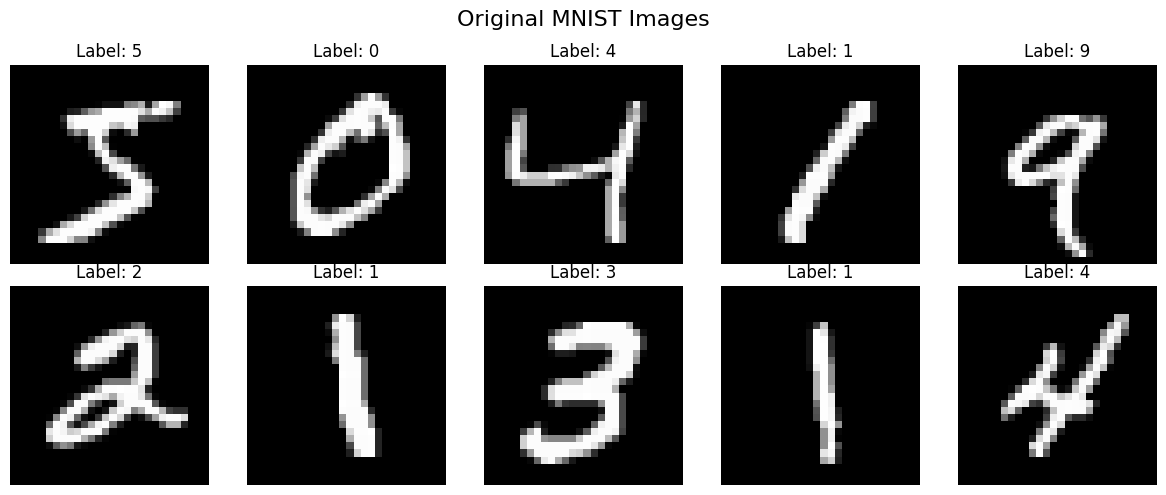

In [3]:
# ============================================================
# CELL 3: Visualize original MNIST images
# ============================================================

fig, axes = plt.subplots(2, 5, figsize=(12, 5))

for i, ax in enumerate(axes.flat):
    ax.imshow(X[i].reshape(28, 28), cmap="gray")
    ax.set_title(f"Label: {y[i]}")
    ax.axis("off")

plt.suptitle("Original MNIST Images", fontsize=16)
plt.tight_layout()
plt.show()

In [4]:
# ============================================================
# CELL 4: Train/test split
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape :", X_test.shape)

Train shape: (56000, 784)
Test shape : (14000, 784)


In [5]:
# ============================================================
# CELL 5: Standardize features
# ============================================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Standardization completed.")
print("Training mean (first 5 features):")
print(np.round(X_train_scaled.mean(axis=0)[:5], 4))

print("\nTraining std (first 5 features):")
print(np.round(X_train_scaled.std(axis=0)[:5], 4))

Standardization completed.
Training mean (first 5 features):
[0. 0. 0. 0. 0.]

Training std (first 5 features):
[0. 0. 0. 0. 0.]


In [6]:
# ============================================================
# CELL 6: Fit full PCA
# ============================================================

print("Fitting PCA...")

start_time = time.time()

pca_full = PCA(
    n_components=None,
    svd_solver="randomized",
    random_state=RANDOM_STATE
)

X_train_pca_full = pca_full.fit_transform(X_train_scaled)

elapsed = time.time() - start_time

print(f"PCA completed in {elapsed:.2f} seconds.")
print(f"Original dimensions: {X_train_scaled.shape[1]}")
print(f"PCA dimensions:      {X_train_pca_full.shape[1]}")

Fitting PCA...
PCA completed in 31.27 seconds.
Original dimensions: 784
PCA dimensions:      784


Components required:
----------------------------------------
80% variance: 149 components
90% variance: 237 components
95% variance: 330 components
99% variance: 542 components


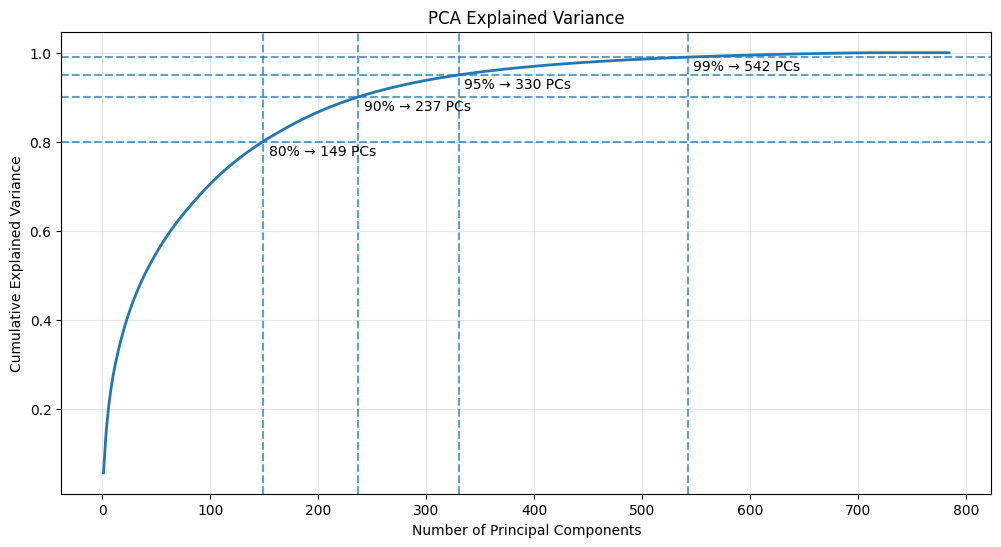

In [7]:
# ============================================================
# CELL 7: Explained variance analysis
# ============================================================

explained_variance = pca_full.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

variance_targets = [0.80, 0.90, 0.95, 0.99]

print("Components required:")
print("-" * 40)

for target in variance_targets:
    n_components = np.argmax(cumulative_variance >= target) + 1
    print(f"{target*100:.0f}% variance: {n_components} components")

plt.figure(figsize=(12, 6))

plt.plot(
    range(1, len(cumulative_variance) + 1),
    cumulative_variance,
    linewidth=2
)

for target in variance_targets:
    n_components = np.argmax(cumulative_variance >= target) + 1

    plt.axhline(
        target,
        linestyle="--",
        alpha=0.7
    )

    plt.axvline(
        n_components,
        linestyle="--",
        alpha=0.7
    )

    plt.text(
        n_components + 5,
        target - 0.03,
        f"{target*100:.0f}% → {n_components} PCs"
    )

plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance")
plt.grid(True, alpha=0.3)
plt.show()

In [8]:
# ============================================================
# CELL 8: Automatically select components for 95% variance
# ============================================================

TARGET_VARIANCE = 0.95

N_COMPONENTS = (
    np.argmax(cumulative_variance >= TARGET_VARIANCE) + 1
)

print(f"Original number of features: {X_train_scaled.shape[1]}")
print(f"Selected PCA components:     {N_COMPONENTS}")
print(
    f"Retained variance:            "
    f"{cumulative_variance[N_COMPONENTS - 1] * 100:.2f}%"
)

reduction_percentage = (
    1 - N_COMPONENTS / X_train_scaled.shape[1]
) * 100

print(
    f"Dimensionality reduction:     "
    f"{reduction_percentage:.2f}%"
)

Original number of features: 784
Selected PCA components:     330
Retained variance:            95.01%
Dimensionality reduction:     57.91%


In [9]:
# ============================================================
# CELL 9: Train final PCA model
# ============================================================

pca = PCA(
    n_components=N_COMPONENTS,
    svd_solver="randomized",
    random_state=RANDOM_STATE
)

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print("PCA feature learning completed.")
print()
print("Before PCA:")
print("  Train:", X_train_scaled.shape)
print("  Test :", X_test_scaled.shape)

print()
print("After PCA:")
print("  Train:", X_train_pca.shape)
print("  Test :", X_test_pca.shape)

PCA feature learning completed.

Before PCA:
  Train: (56000, 784)
  Test : (14000, 784)

After PCA:
  Train: (56000, 330)
  Test : (14000, 330)


In [10]:
# ============================================================
# CELL 10: PCA reconstruction / decoder
# ============================================================

X_test_reconstructed_scaled = pca.inverse_transform(X_test_pca)

# Convert reconstructed standardized values back
# into the original pixel scale.
X_test_reconstructed = scaler.inverse_transform(
    X_test_reconstructed_scaled
)

print("Original test shape:      ", X_test.shape)
print("Latent PCA shape:         ", X_test_pca.shape)
print("Reconstructed test shape: ", X_test_reconstructed.shape)

Original test shape:       (14000, 784)
Latent PCA shape:          (14000, 330)
Reconstructed test shape:  (14000, 784)


In [11]:
# ============================================================
# CELL 11: Reconstruction error
# ============================================================

mse = mean_squared_error(
    X_test_scaled,
    X_test_reconstructed_scaled
)

rmse = np.sqrt(mse)

print(f"Reconstruction MSE : {mse:.6f}")
print(f"Reconstruction RMSE: {rmse:.6f}")

Reconstruction MSE : 0.425057
Reconstruction RMSE: 0.651964


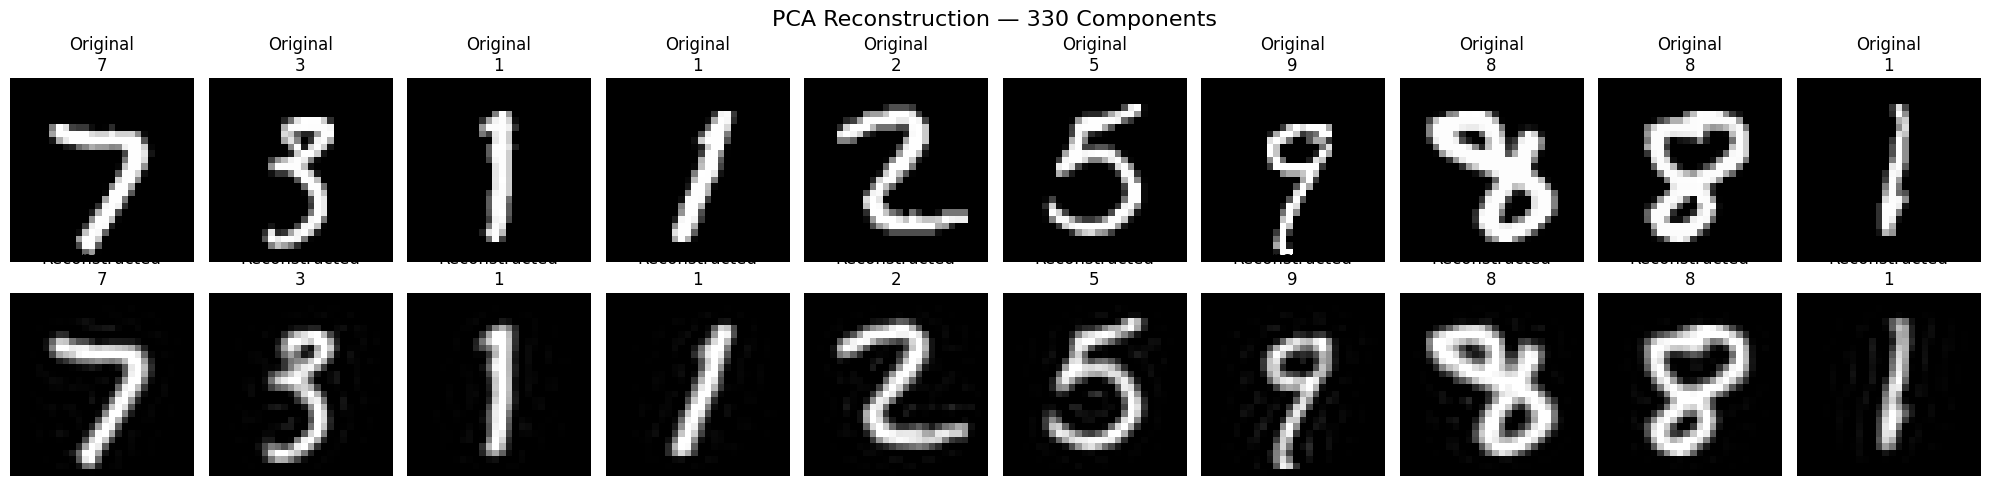

In [12]:
# ============================================================
# CELL 12: Original vs reconstructed images
# ============================================================

n_images = 10

fig, axes = plt.subplots(
    2,
    n_images,
    figsize=(20, 5)
)

for i in range(n_images):

    # Original
    axes[0, i].imshow(
        X_test[i].reshape(28, 28),
        cmap="gray"
    )
    axes[0, i].set_title(
        f"Original\n{y_test[i]}"
    )
    axes[0, i].axis("off")

    # Reconstruction
    reconstructed = np.clip(
        X_test_reconstructed[i],
        0,
        255
    )

    axes[1, i].imshow(
        reconstructed.reshape(28, 28),
        cmap="gray"
    )
    axes[1, i].set_title(
        f"Reconstructed\n{y_test[i]}"
    )
    axes[1, i].axis("off")

axes[0, 0].set_ylabel("Original", fontsize=12)
axes[1, 0].set_ylabel("PCA Reconstruction", fontsize=12)

plt.suptitle(
    f"PCA Reconstruction — {N_COMPONENTS} Components",
    fontsize=16
)

plt.tight_layout()
plt.show()

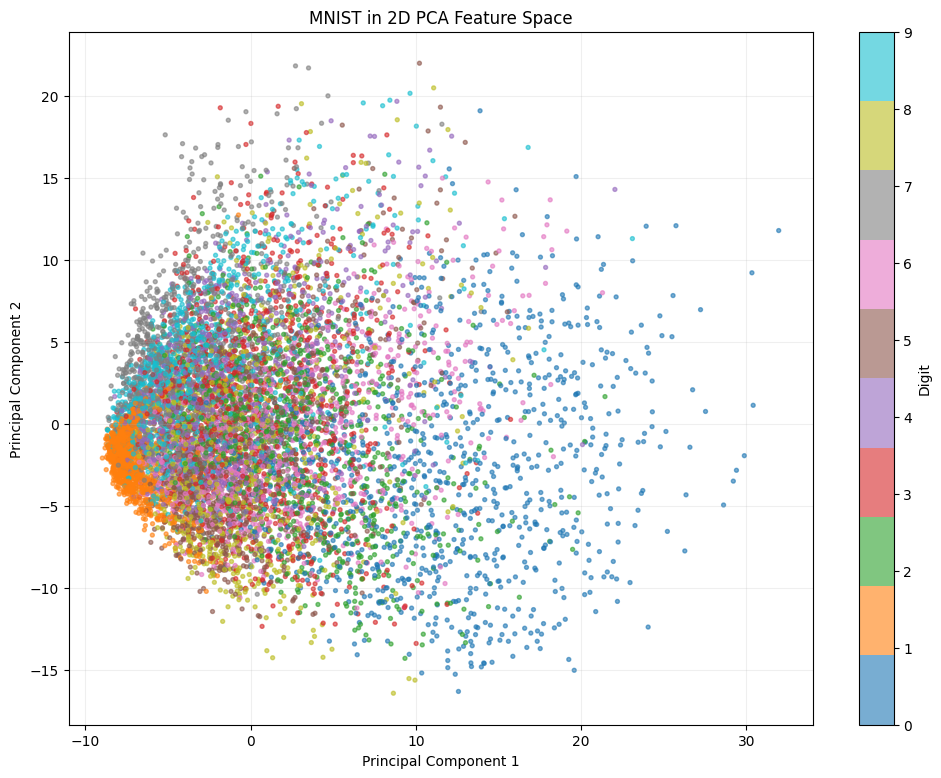

In [13]:
# ============================================================
# CELL 13: 2D PCA visualization
# ============================================================

pca_2d = PCA(
    n_components=2,
    random_state=RANDOM_STATE
)

X_train_2d = pca_2d.fit_transform(X_train_scaled)

# Plot a manageable subset for visualization
VISUALIZATION_SAMPLES = 10000

X_vis = X_train_2d[:VISUALIZATION_SAMPLES]
y_vis = y_train[:VISUALIZATION_SAMPLES]

plt.figure(figsize=(12, 9))

scatter = plt.scatter(
    X_vis[:, 0],
    X_vis[:, 1],
    c=y_vis,
    cmap="tab10",
    s=8,
    alpha=0.6
)

plt.colorbar(
    scatter,
    label="Digit"
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("MNIST in 2D PCA Feature Space")
plt.grid(alpha=0.2)
plt.show()

In [14]:
# ============================================================
# CELL 14: Classification using PCA features
# ============================================================

print("Training Logistic Regression on PCA features...")

# Removed deprecated 'multi_class' parameter to ensure compatibility with newer scikit-learn versions.
classifier_pca = LogisticRegression(
    max_iter=1000,
    solver="lbfgs",
    random_state=RANDOM_STATE
)

start_time = time.time()

classifier_pca.fit(
    X_train_pca,
    y_train
)

training_time = time.time() - start_time

y_pred_pca = classifier_pca.predict(X_test_pca)

accuracy_pca = accuracy_score(
    y_test,
    y_pred_pca
)

print(f"Training time: {training_time:.2f} seconds")
print(f"PCA feature classification accuracy: {accuracy_pca:.4f}")

Training Logistic Regression on PCA features...
Training time: 54.58 seconds
PCA feature classification accuracy: 0.9195


In [15]:
# ============================================================
# CELL 15: Baseline classifier using original features
# ============================================================

print("Training baseline Logistic Regression...")

classifier_original = LogisticRegression(
    max_iter=1000,
    solver="lbfgs",
    random_state=RANDOM_STATE
)

start_time = time.time()

classifier_original.fit(
    X_train_scaled,
    y_train
)

baseline_training_time = time.time() - start_time

y_pred_original = classifier_original.predict(
    X_test_scaled
)

accuracy_original = accuracy_score(
    y_test,
    y_pred_original
)

print(
    f"Original feature classification accuracy: "
    f"{accuracy_original:.4f}"
)

print(
    f"PCA feature classification accuracy:      "
    f"{accuracy_pca:.4f}"
)

print(
    f"Original training time: "
    f"{baseline_training_time:.2f} seconds"
)

print(
    f"PCA training time:      "
    f"{training_time:.2f} seconds"
)

Training baseline Logistic Regression...
Original feature classification accuracy: 0.9163
PCA feature classification accuracy:      0.9195
Original training time: 58.40 seconds
PCA training time:      54.58 seconds


In [ ]:
# ============================================================
# CELL 16: Classification report
# ============================================================

print("Classification Report — PCA Features")
print("=" * 60)

print(
    classification_report(
        y_test,
        y_pred_pca,
        digits=4
    )
)

Classification Report — PCA Features
              precision    recall  f1-score   support

           0     0.9464    0.9710    0.9585      1381
           1     0.9515    0.9708    0.9610      1575
           2     0.9181    0.8906    0.9041      1398
           3     0.9032    0.8887    0.8959      1428
           4     0.9214    0.9194    0.9204      1365
           5     0.8922    0.8717    0.8819      1263
           6     0.9332    0.9556    0.9443      1375
           7     0.9276    0.9397    0.9336      1459
           8     0.8929    0.8857    0.8893      1365
           9     0.9014    0.8936    0.8975      1391

    accuracy                         0.9198     14000
   macro avg     0.9188    0.9187    0.9187     14000
weighted avg     0.9195    0.9198    0.9195     14000



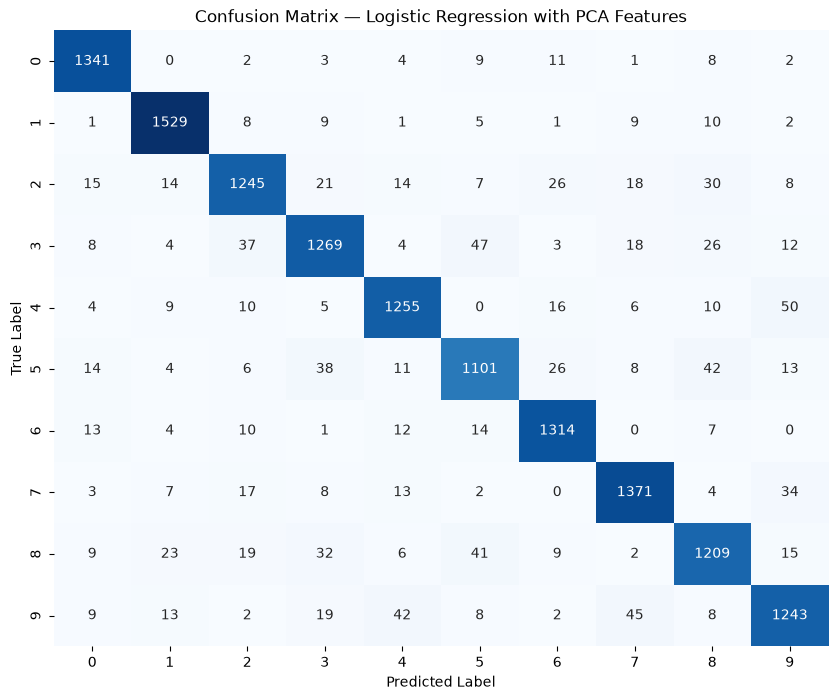

In [ ]:
# ============================================================
# CELL 17: Confusion matrix
# ============================================================

cm = confusion_matrix(
    y_test,
    y_pred_pca
)

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix — Logistic Regression with PCA Features")

plt.show()

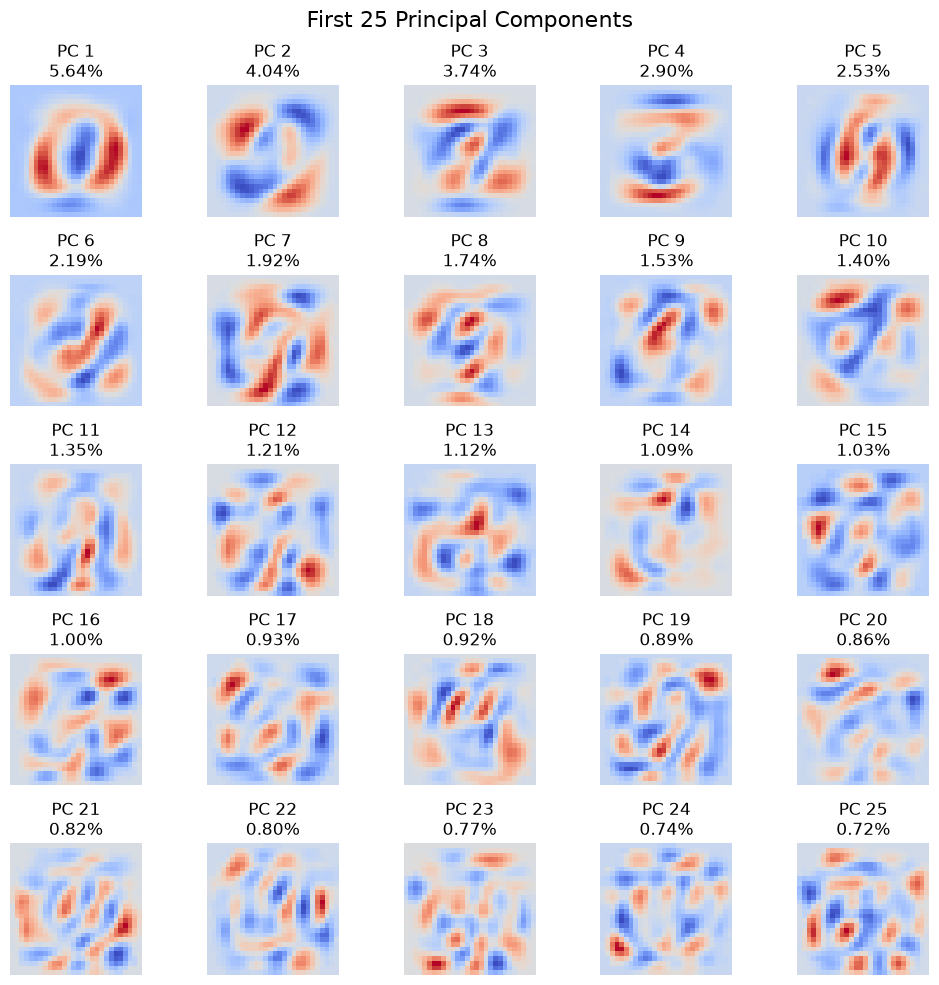

In [ ]:
# ============================================================
# CELL 18: Visualize PCA components
# ============================================================

n_components_to_show = min(25, N_COMPONENTS)

fig, axes = plt.subplots(
    5,
    5,
    figsize=(10, 10)
)

for i, ax in enumerate(axes.flat):

    if i < n_components_to_show:

        component = pca.components_[i]

        ax.imshow(
            component.reshape(28, 28),
            cmap="coolwarm"
        )

        ax.set_title(
            f"PC {i + 1}\n"
            f"{pca.explained_variance_ratio_[i] * 100:.2f}%"
        )

    ax.axis("off")

plt.suptitle(
    "First 25 Principal Components",
    fontsize=16
)

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# CELL 19: Compare reconstruction at different dimensions
# ============================================================

component_values = [
    10,
    25,
    50,
    100,
    min(200, X_train_scaled.shape[1])
]

component_values = sorted(
    set(component_values)
)

results = []

for n in component_values:

    pca_temp = PCA(
        n_components=n,
        svd_solver="randomized",
        random_state=RANDOM_STATE
    )

    X_train_temp = pca_temp.fit_transform(
        X_train_scaled
    )

    X_test_temp = pca_temp.transform(
        X_test_scaled
    )

    X_test_reconstructed_temp = (
        pca_temp.inverse_transform(X_test_temp)
    )

    reconstruction_mse = mean_squared_error(
        X_test_scaled,
        X_test_reconstructed_temp
    )

    variance_retained = (
        np.sum(
            pca_temp.explained_variance_ratio_
        )
    )

    results.append({
        "Components": n,
        "Variance Retained": variance_retained,
        "Reconstruction MSE": reconstruction_mse
    })

results_df = pd.DataFrame(results)

print(results_df.to_string(index=False))

 Components  Variance Retained  Reconstruction MSE
         10           0.276390            8.850219
         25           0.418876            8.691373
         50           0.550391            7.974060
        100           0.703140            6.985235
        200           0.865602            5.602074


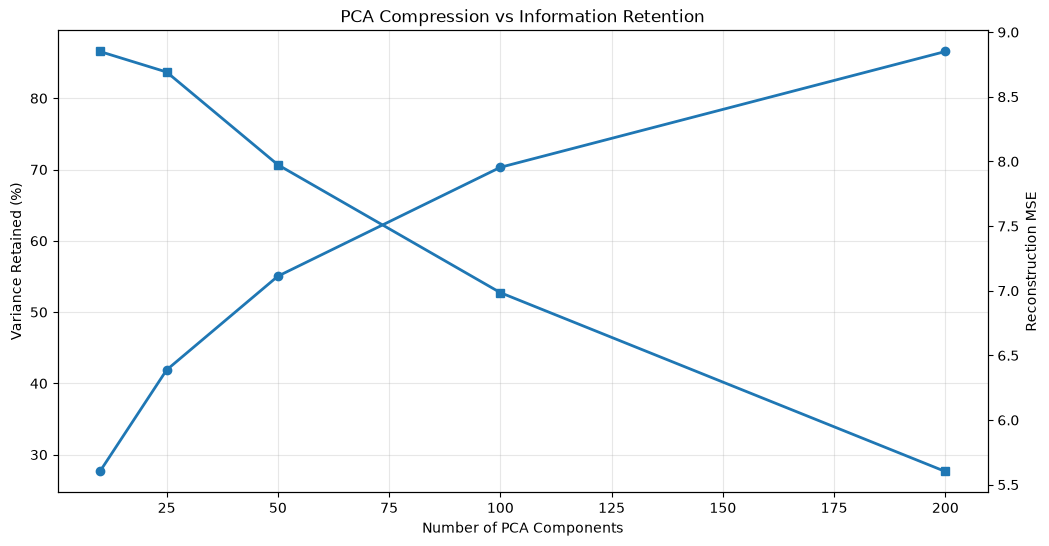

In [ ]:
# ============================================================
# CELL 20: PCA dimensionality trade-off
# ============================================================

fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.plot(
    results_df["Components"],
    results_df["Variance Retained"] * 100,
    marker="o",
    linewidth=2
)

ax1.set_xlabel("Number of PCA Components")
ax1.set_ylabel("Variance Retained (%)")
ax1.set_title("PCA Compression vs Information Retention")
ax1.grid(alpha=0.3)

ax2 = ax1.twinx()

ax2.plot(
    results_df["Components"],
    results_df["Reconstruction MSE"],
    marker="s",
    linewidth=2
)

ax2.set_ylabel("Reconstruction MSE")

plt.show()

In [ ]:
# ============================================================
# CELL 21: Save trained models
# ============================================================

import joblib

MODEL_PATH = "/content/mnist_pca_pipeline.pkl"

model_bundle = {
    "scaler": scaler,
    "pca": pca,
    "classifier": classifier_pca,
    "n_components": N_COMPONENTS,
    "target_variance": TARGET_VARIANCE
}

joblib.dump(
    model_bundle,
    MODEL_PATH
)

print(f"Model saved to: {MODEL_PATH}")

Model saved to: /content/mnist_pca_pipeline.pkl


In [ ]:
# ============================================================
# CELL 22: Load model and perform inference
# ============================================================

loaded_model = joblib.load(
    MODEL_PATH
)

loaded_scaler = loaded_model["scaler"]
loaded_pca = loaded_model["pca"]
loaded_classifier = loaded_model["classifier"]

# Take one unseen test image
sample = X_test[0].reshape(1, -1)

# Scale
sample_scaled = loaded_scaler.transform(
    sample
)

# PCA encoding
sample_latent = loaded_pca.transform(
    sample_scaled
)

# Classification
prediction = loaded_classifier.predict(
    sample_latent
)

print("Original image label:", y_test[0])
print("Predicted label:     ", prediction[0])
print("Latent representation shape:", sample_latent.shape)

Original image label: 7
Predicted label:      7
Latent representation shape: (1, 330)


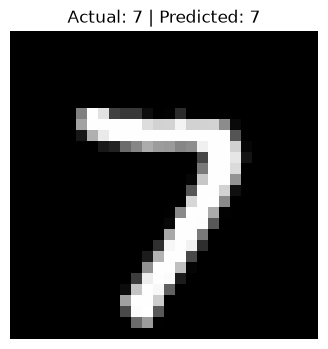

In [ ]:
# ============================================================
# CELL 23: Display inference result
# ============================================================

plt.figure(figsize=(4, 4))

plt.imshow(
    X_test[0].reshape(28, 28),
    cmap="gray"
)

plt.title(
    f"Actual: {y_test[0]} | "
    f"Predicted: {prediction[0]}"
)

plt.axis("off")
plt.show()

In [ ]:
# ============================================================
# CELL 24: Final results summary
# ============================================================

original_dimensions = X_train_scaled.shape[1]
compressed_dimensions = X_train_pca.shape[1]

variance_retained = (
    np.sum(pca.explained_variance_ratio_)
)

compression_ratio = (
    original_dimensions / compressed_dimensions
)

dimension_reduction = (
    1 - compressed_dimensions / original_dimensions
) * 100

summary = pd.DataFrame({
    "Metric": [
        "Original Features",
        "PCA Features",
        "Variance Retained",
        "Dimensionality Reduction",
        "Compression Ratio",
        "Reconstruction MSE",
        "PCA Classification Accuracy",
        "Original Classification Accuracy"
    ],
    "Value": [
        original_dimensions,
        compressed_dimensions,
        f"{variance_retained * 100:.2f}%",
        f"{dimension_reduction:.2f}%",
        f"{compression_ratio:.2f}x",
        f"{mse:.6f}",
        f"{accuracy_pca:.4f}",
        f"{accuracy_original:.4f}"
    ]
})

print(summary.to_string(index=False))

                          Metric    Value
               Original Features      784
                    PCA Features      330
               Variance Retained   94.96%
        Dimensionality Reduction   57.91%
               Compression Ratio    2.38x
              Reconstruction MSE 0.425050
     PCA Classification Accuracy   0.9198
Original Classification Accuracy   0.9163
